# Supervised Learning - Foundations Project: ReCell

## Problem Statement

### Business Context

Buying and selling used phones and tablets used to be something that happened on a handful of online marketplace sites. But the used and refurbished device market has grown considerably over the past decade, and a new IDC (International Data Corporation) forecast predicts that the used phone market would be worth \\$52.7bn by 2023 with a compound annual growth rate (CAGR) of 13.6% from 2018 to 2023. This growth can be attributed to an uptick in demand for used phones and tablets that offer considerable savings compared with new models.

Refurbished and used devices continue to provide cost-effective alternatives to both consumers and businesses that are looking to save money when purchasing one. There are plenty of other benefits associated with the used device market. Used and refurbished devices can be sold with warranties and can also be insured with proof of purchase. Third-party vendors/platforms, such as Verizon, Amazon, etc., provide attractive offers to customers for refurbished devices. Maximizing the longevity of devices through second-hand trade also reduces their environmental impact and helps in recycling and reducing waste. The impact of the COVID-19 outbreak may further boost this segment as consumers cut back on discretionary spending and buy phones and tablets only for immediate needs.


### Objective

The rising potential of this comparatively under-the-radar market fuels the need for an ML-based solution to develop a dynamic pricing strategy for used and refurbished devices. ReCell, a startup aiming to tap the potential in this market, has hired you as a data scientist. They want you to analyze the data provided and build a linear regression model to predict the price of a used phone/tablet and identify factors that significantly influence it.


### Data Description

The data contains the different attributes of used/refurbished phones and tablets. The data was collected in the year 2021. The detailed data dictionary is given below.


- brand_name: Name of manufacturing brand
- os: OS on which the device runs
- screen_size: Size of the screen in cm
- 4g: Whether 4G is available or not
- 5g: Whether 5G is available or not
- main_camera_mp: Resolution of the rear camera in megapixels
- selfie_camera_mp: Resolution of the front camera in megapixels
- int_memory: Amount of internal memory (ROM) in GB
- ram: Amount of RAM in GB
- battery: Energy capacity of the device battery in mAh
- weight: Weight of the device in grams
- release_year: Year when the device model was released
- days_used: Number of days the used/refurbished device has been used
- normalized_new_price: Normalized price of a new device of the same model in euros
- normalized_used_price: Normalized price of the used/refurbished device in euros

## Importing necessary libraries

In [1]:
# Installing the libraries with the specified version.
# uncomment and run the following line if Google Colab is being used
!pip install scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.3 -q --user

In [2]:
# Installing the libraries with the specified version.
# uncomment and run the following lines if Jupyter Notebook is being used
# !pip install scikit-learn==1.2.2 seaborn==0.11.1 matplotlib==3.3.4 numpy==1.24.3 pandas==1.5.2 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [2]:
# for data manipulation
import pandas as pd
import numpy as np

#for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# for data spliting
from sklearn.model_selection import train_test_split

# To build linear regression model
import statsmodels.api as sm

# to check model performance
from sklearn.metrics import mean_squared_error, mean_absolute_error

# to compute VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor



## Loading the dataset

In [196]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [197]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/used_device_data.csv')
df.head()

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
0,Honor,Android,14.50,yes,no,13.0,5.0,64.0,3.0,3020.0,146.0,2020,127,4.307572,4.715100
1,Honor,Android,17.30,yes,yes,13.0,16.0,128.0,8.0,4300.0,213.0,2020,325,5.162097,5.519018
2,Honor,Android,16.69,yes,yes,13.0,8.0,128.0,8.0,4200.0,213.0,2020,162,5.111084,5.884631
3,Honor,Android,25.50,yes,yes,13.0,8.0,64.0,6.0,7250.0,480.0,2020,345,5.135387,5.630961
4,Honor,Android,15.32,yes,no,13.0,8.0,64.0,3.0,5000.0,185.0,2020,293,4.389995,4.947837


## Data Overview

- Observations
- Sanity checks

In [5]:
df.shape # Checking of number of rows and columns in the dataset

(3454, 15)

In [6]:
df.info() #checking for datatypes of the columns present in the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3454 entries, 0 to 3453
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand_name             3454 non-null   object 
 1   os                     3454 non-null   object 
 2   screen_size            3454 non-null   float64
 3   4g                     3454 non-null   object 
 4   5g                     3454 non-null   object 
 5   main_camera_mp         3275 non-null   float64
 6   selfie_camera_mp       3452 non-null   float64
 7   int_memory             3450 non-null   float64
 8   ram                    3450 non-null   float64
 9   battery                3448 non-null   float64
 10  weight                 3447 non-null   float64
 11  release_year           3454 non-null   int64  
 12  days_used              3454 non-null   int64  
 13  normalized_used_price  3454 non-null   float64
 14  normalized_new_price   3454 non-null   float64
dtypes: f

In [7]:
df.describe() #checking for basic stats from the dataset

,screen_size,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
count,3454.000000,3275.000000,3452.000000,3450.000000,3450.000000,3448.000000,3447.000000,3454.000000,3454.000000,3454.000000,3454.000000
mean,13.713115,9.460208,6.554229,54.573099,4.036122,3133.402697,182.751871,2015.965258,674.869716,4.364712,5.233107
std,3.805280,4.815461,6.970372,84.972371,1.365105,1299.682844,88.413228,2.298455,248.580166,0.588914,0.683637
min,5.080000,0.080000,0.000000,0.010000,0.020000,500.000000,69.000000,2013.000000,91.000000,1.536867,2.901422
25%,12.700000,5.000000,2.000000,16.000000,4.000000,2100.000000,142.000000,2014.000000,533.500000,4.033931,4.790342
50%,12.830000,8.000000,5.000000,32.000000,4.000000,3000.000000,160.000000,2015.500000,690.500000,4.405133,5.245892
75%,15.340000,13.000000,8.000000,64.000000,4.000000,4000.000000,185.000000,2018.000000,868.750000,4.755700,5.673718
max,30.710000,48.000000,32.000000,1024.000000,12.000000,9720.000000,855.000000,2020.000000,1094.000000,6.619433,7.847841


In [8]:
df.isnull().sum() #checking for number for null values present in each column

,0
brand_name,0
os,0
screen_size,0
4g,0
5g,0
main_camera_mp,179
selfie_camera_mp,2
int_memory,4
ram,4
battery,6


In [189]:
df.duplicated().sum() #checking for number of duplicated rows in the dataset

0

Initial Observations -
1. There are no duplicate rows.
2. There are some missing data that will be handled in the following sections.
3. There are 3454 rows of data with 15 attributes.



## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What does the distribution of normalized used device prices look like?
Ans: From the graph below, the distribution is almost a normal distribution.

2. What percentage of the used device market is dominated by Android devices?
Ans: 93% of the used device market is dominated by Andriod Devices.

3. The amount of RAM is important for the smooth functioning of a device. How does the amount of RAM vary with the brand?
4. A large battery often increases a device's weight, making it feel uncomfortable in the hands. How does the weight vary for phones and tablets offering large batteries (more than 4500 mAh)?
5. Bigger screens are desirable for entertainment purposes as they offer a better viewing experience. How many phones and tablets are available across different brands with a screen size larger than 6 inches?
6. A lot of devices nowadays offer great selfie cameras, allowing us to capture our favorite moments with loved ones. What is the distribution of devices offering greater than 8MP selfie cameras across brands?
7. Which attributes are highly correlated with the normalized price of a used device?

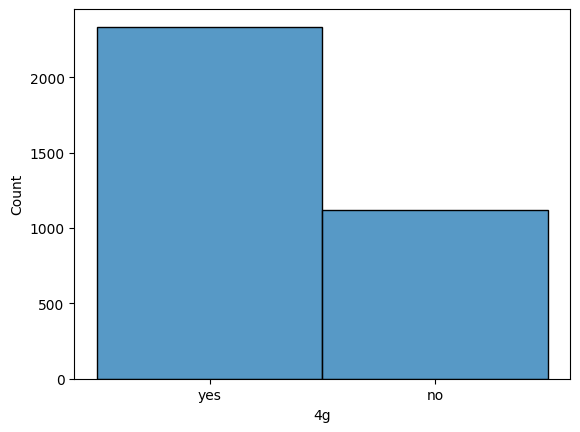

In [193]:
# Histplot of 4g
sns.histplot(df['4g'])
plt.show()

Most of devices are 4g compatible.

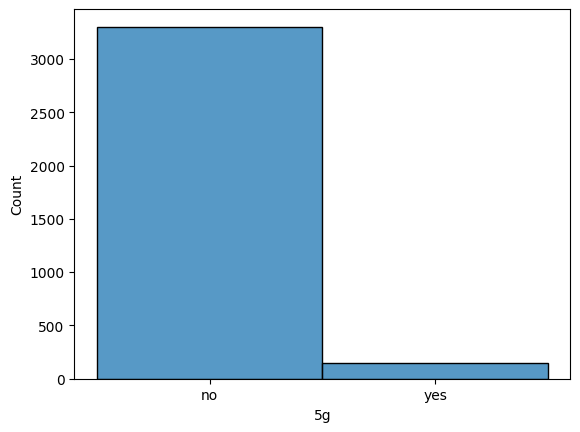

In [194]:
# Histplot of 5g
sns.histplot(df['5g'])
plt.show()

Most of the devices are not 5g compatible.

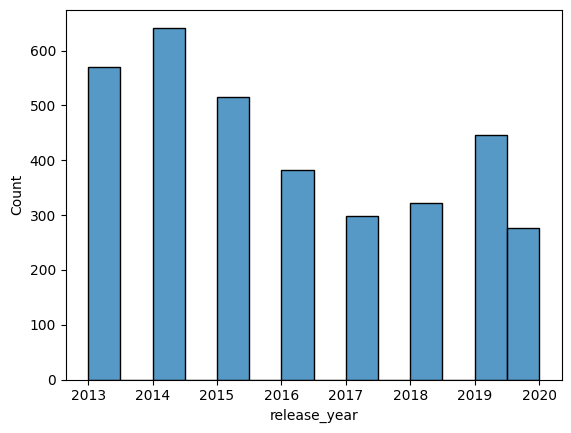

In [200]:
sns.(df['release_year'])
plt.show()

Most models are from 2014 that are refurbished.

**Question 1 -**

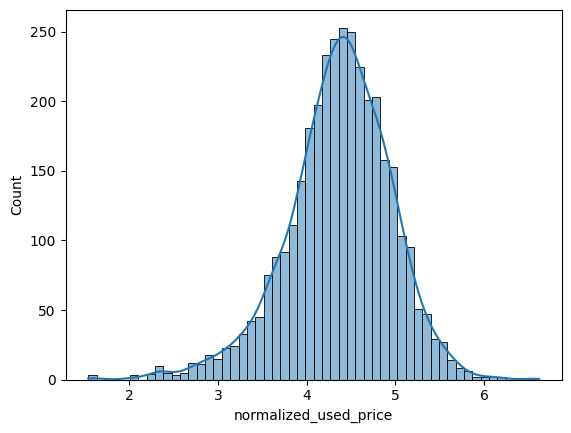

In [9]:
# distribution of normalized used device prices
sns.histplot(df['normalized_used_price'], kde = True)
plt.show()

We can see that the 'normalized_used_price' distribution exibits a curve similar to the normal distribution curve.

**Question 2 -**

In [10]:
# Percentage of used device dominated by Andriod users
df['os'].value_counts(normalize = True)

,os
Android,0.930515
Others,0.039664
Windows,0.019398
iOS,0.010423


In [11]:
df['brand_name'].value_counts(normalize=True, ascending=False)

,brand_name
Others,0.145339
Samsung,0.098726
Huawei,0.072669
LG,0.058193
Lenovo,0.049508
ZTE,0.040533
Xiaomi,0.038217
Oppo,0.037348
Asus,0.035321
Alcatel,0.035032


**OS:** The Andriod phones dominate the used phones market as 93% are andriod phones.

**Brands:** 'Other' brands are around 14.5% of market followed by Samsung at 9.8% and Huawei at 7.2%

**Question 3:**

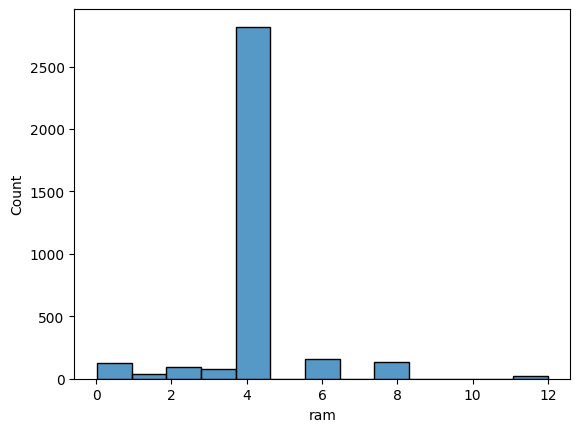

In [86]:
sns.histplot(df['ram'])
plt.show()

Most devices have 4GBs of RAM.

In [12]:
# Mean RAM based on Brands
df.groupby('brand_name')['ram'].mean().sort_values(ascending = False)

,ram
brand_name,
OnePlus,6.363636
Oppo,4.961240
Vivo,4.756410
Huawei,4.655378
Honor,4.603448
Xiaomi,4.583333
Google,4.533333
Meizu,4.451613
Samsung,4.199413


**RAM:** From the table we can see that OnePlus phones usually have more RAM with mean being above 6GBs of RAM, while Celkon phones have the lower RAMs with 1.61 GBs as the mean.

**Question 4:**

In [13]:
# Mean weight of phones with large batteries more that 4500 mAH
LargeBattery_meanweight = df[df['battery'] > 4500]['weight'].mean()

In [14]:
# Mean weight of phones with batteries less than or equal to 4500 mAH
SmallBattery_meanweight = df[df['battery']<= 4500]['weight'].mean()

print(f'Mean weight of phones with large batteries more that 4500 mAH: {LargeBattery_meanweight}')
print(f'Mean weight of phones with batteries less than or equal to 4500 mAH: {SmallBattery_meanweight}')
print(f'Difference in weight: {LargeBattery_meanweight - SmallBattery_meanweight}')

Mean weight of phones with large batteries more that 4500 mAH: 332.2756598240469
Mean weight of phones with batteries less than or equal to 4500 mAH: 166.242
Difference in weight: 166.0336598240469


**Battery and phone weight**: The phones with battery capacity more than 4500 mAH tend to be lot heavier with mean weight 332.27 gm (almost twice) than phones with battery capacity less than or equal to 4500 mAH with mean weight 166.242 gms.

**Question 5:**

In [109]:
# Number of phones and tablets with screen size more than 6 inches

df[df['screen_size'] > 15.24].shape

(1099, 15)

There are 1099 phone available across different brands that have screen size more than 6 inches (15.24 cm). You can view the number of devices having screen size more than 6 inches grouped by brands below.

In [110]:
df[df['screen_size'] > 15.24].groupby('brand_name').size() # No of devices having screen size more than 6 inches grouped by brands

,0
brand_name,
Acer,19
Alcatel,26
Apple,24
Asus,41
Coolpad,3
Gionee,3
Google,4
HTC,7
Honor,72


**Question 6:**

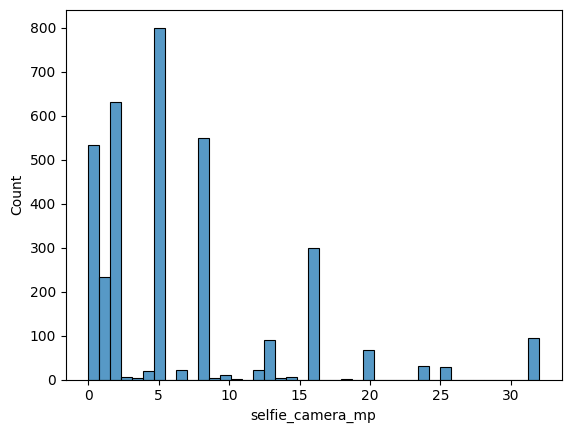

In [17]:
# Distribution of devices offering greater than 8 MP selfie cameras across brands
sns.histplot(x = 'selfie_camera_mp', data = df)
plt.show()

In [18]:
df[df['selfie_camera_mp']>8].shape

(655, 15)

Most devices have 5 MP of selfie camera mp.
655 used phones offer selfie camera with more than 8MP across all brands. Below you can find number of phones grouped by brands.

In [19]:
df[df['selfie_camera_mp']>8].groupby('brand_name').size()

,0
brand_name,
Acer,1
Asus,6
BlackBerry,2
Coolpad,3
Gionee,4
HTC,20
Honor,41
Huawei,87
Infinix,4


<ipython-input-20-6b2f6f03d9f8>:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')


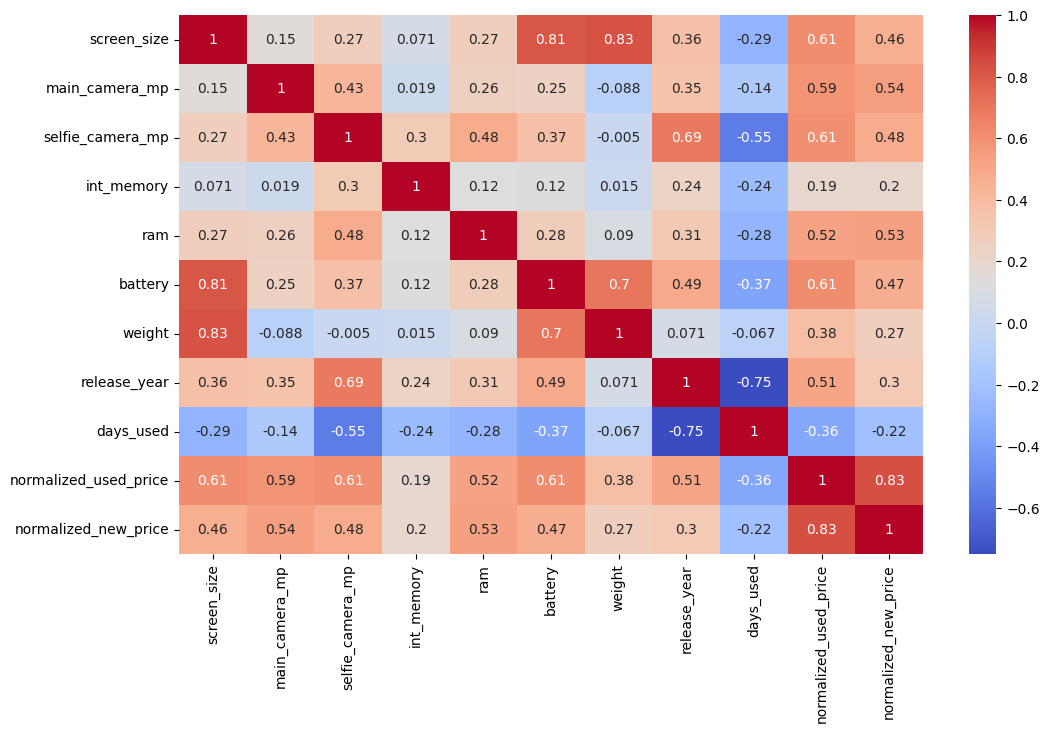

In [20]:
# Heatmap to check correlation between the attributes
plt.figure(figsize=(12, 7))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')
plt.show()

**Question 7:**

In [21]:
# Correlation matrix to find highly correlated attributes with the normalized price of a used device
df.corr()['normalized_used_price'].sort_values(ascending = False)

<ipython-input-21-9a42973eca61>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()['normalized_used_price'].sort_values(ascending = False)


,normalized_used_price
normalized_used_price,1.000000
normalized_new_price,0.834496
screen_size,0.614785
battery,0.613619
selfie_camera_mp,0.608074
main_camera_mp,0.587302
ram,0.520289
release_year,0.509790
weight,0.382354
int_memory,0.190993


The attributes that have a high correlation with 'normalized_used_price are -
1. normalized_new_price
2. screen_size
3. battery

Only 'days_used' attribute show a negative correlation with the normalized_user_price. That means the price drops as the days_used increases.

Bi- Variate Analysis -

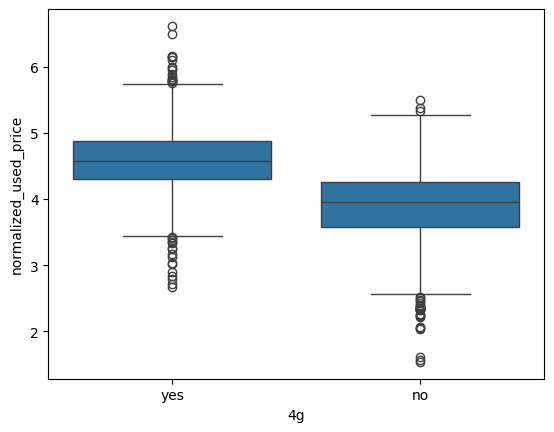

In [201]:
# Box plot for 4g compatible phones as used price
sns.boxplot (data= df, x = '4g', y = 'normalized_used_price')
plt.show()

The mean price for 4g compatible devices is more than non compatible

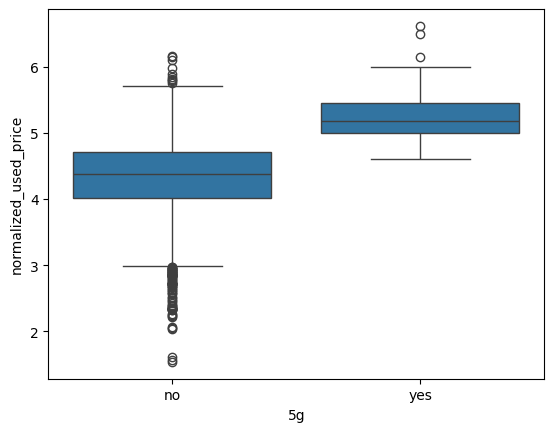

In [202]:
# box plot for 5g compatible phones
sns.boxplot (data= df, x = '5g', y = 'normalized_used_price')
plt.show()

5G compatible phones have higher price than non compatible phones.

## Data Preprocessing

- Missing value treatment
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

# **Missing Value Treatment**

*Checking for missing values*

In [22]:
df.isnull().sum()

,0
brand_name,0
os,0
screen_size,0
4g,0
5g,0
main_camera_mp,179
selfie_camera_mp,2
int_memory,4
ram,4
battery,6


As we can see 'main_camera_mp' has the most number of missing values, lets treat the attribute accordingly.

**1. Treating missing values for 'main_camera_mp'** : 179 missing values.

In [23]:
df['main_camera_mp'].mean() # Calculating the mean of main camera before treating missing values

9.460207633587787

In [24]:
df['main_camera_mp'].fillna(df['main_camera_mp'].mean(), inplace = True) # Treating the missing values with the mean value.

In [25]:
df['main_camera_mp'].isnull().sum() # Checking for missing values

0

In [26]:
df['main_camera_mp'].mean() # Checking for mean after treating missing values

9.460207633587787

The mean did not change. Lets follow a similar path for treat other numeric attributes.

**2. Treating missing values of 'selfie_camera_mp'**: 2 missing values

In [27]:
df['selfie_camera_mp'].mean() # Checking for mean

6.554229432213209

In [28]:
df['selfie_camera_mp'].fillna(df['selfie_camera_mp'].mean(), inplace = True) # Treating the missing values with the mean value.

In [29]:
df['selfie_camera_mp'].isnull().sum() # Checking for missing values

0

In [30]:
df['selfie_camera_mp'].mean() # Checking for mean after treating missing values

6.5542294322132095

The mean did not change and no missing values in the "self_camera_mp" attribute

**3. Treating missing values of 'int_memory':** 4 missing values

In [31]:
df['int_memory'].mean() # Checking for mean

54.57309855072464

In [32]:
df['int_memory'].fillna(df['int_memory'].mean(), inplace = True) # Treating the missing values with the mean value.

In [33]:
df['int_memory'].isnull().sum() # Checking for missing values

0

In [34]:
df['int_memory'].mean() # Checking for mean after treating missing values

54.57309855072464

**4. Treating missing values of 'ram'**: 4 missing values

In [35]:
df['ram'].mean() # Checking for mean

4.036121739130435

In [36]:
df['ram'].fillna(df['ram'].mean(), inplace = True) # Treating the missing values with the mean value.

In [37]:
df['ram'].isnull().sum() # Checking for missing values

0

In [38]:
df['ram'].mean() # Checking for mean after treating missing values

4.036121739130435

No more missing values and the mean did not change.

**5. Treating missing values of 'battery'**: 6 missing values

In [39]:
df['battery'].mean() # Checking for mean

3133.402697215777

In [40]:
df['battery'].fillna(df['battery'].mean(), inplace = True) # Treating the missing values with the mean value.

In [41]:
df['battery'].isnull().sum() # Checking for missing values

0

In [42]:
df['battery'].mean() # Checking for mean after treating missing values

3133.402697215777

No missing values and mean did not change

6. **Treating missing values of 'weight':** 7 missing values

In [43]:
df['weight'].mean() # Checking for mean

182.75187119234116

In [44]:
df['weight'].fillna(df['weight'].mean(), inplace = True) # Treating the missing values with the mean value.

In [45]:
df['weight'].isnull().sum() # Checking for missing values

0

In [46]:
df['weight'].mean() # Checking for mean after treating missing values

182.75187119234118

No Missing values in 'weight' and the mean did not change.

In [47]:
# Checking for any missing values after treatment
df.isnull().sum()

,0
brand_name,0
os,0
screen_size,0
4g,0
5g,0
main_camera_mp,0
selfie_camera_mp,0
int_memory,0
ram,0
battery,0


There are no values missing in the dataset.

**Outlier Detection:**

1. 'normalized_new_price'

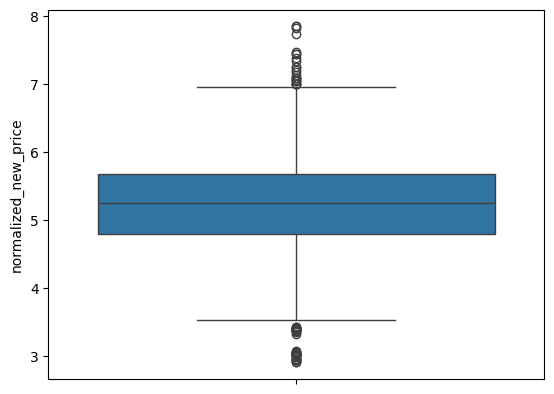

In [48]:
# Visualizing using box plot
sns.boxplot(df['normalized_new_price'])
plt.show()

In [72]:
# Computing outlier rows and columns for 'normalized_new_price' attribute
IQR = df['normalized_new_price'].quantile(0.75) - df['normalized_new_price'].quantile(0.25)
lower_limit = df['normalized_new_price'].quantile(0.25) - (IQR * 1.5)
upper_limit = df['normalized_new_price'].quantile(0.75) + (IQR * 1.5)

outliers_newprice = df[(df['normalized_new_price'] < lower_limit) | (df['normalized_new_price'] > upper_limit)]

print("Outlier:\n", outliers_newprice.shape)

Outlier:
 (66, 15)


There are 66 outliers from the dataset for normalized new price, more investigation is required on the accuracy of these rows. Some phones could be cheaper and others could be really expensive depending on the selling point and features, the outliers look natural.

2. 'screen_size'

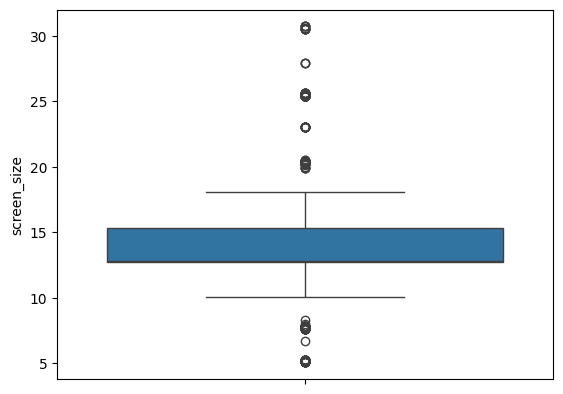

In [50]:
# Visualizing using box plot
sns.boxplot(df['screen_size'])
plt.show()

In [71]:
# Computing outlier rows and columns for 'screen_size' attribute
IQR = df['screen_size'].quantile(0.75) - df['screen_size'].quantile(0.25)
lower_limit = df['screen_size'].quantile(0.25) - (IQR * 1.5)
upper_limit = df['screen_size'].quantile(0.75) + (IQR * 1.5)

outliers_screensize = df[(df['screen_size'] < lower_limit)]

print("Outlier:\n", outliers_screensize.shape)

Outlier:
 (198, 15)


In [68]:
outliers_screensize['screen_size'].describe()

,screen_size
count,198.000000
mean,6.550960
std,1.265171
min,5.080000
25%,5.180000
50%,7.620000
75%,7.750000
max,8.310000


Looking at the screen sizes from the outliers data set, the mean screen size is 6.5 cms that is around 2 inches. These screen sizes are quite small as compared to the mean of the dataset, more analysis is required to investigate the accuracy of these rows. Maybe few phones are not touch screen phones.

**3. Weight**

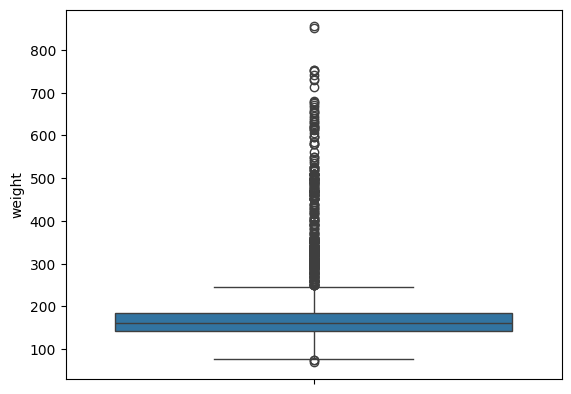

In [74]:
# Visualizing using box plot
sns.boxplot(df['weight'])
plt.show()

In [76]:
# Computing outlier rows and columns for 'weight' attribute
IQR = df['weight'].quantile(0.75) - df['weight'].quantile(0.25)
lower_limit = df['weight'].quantile(0.25) - (IQR * 1.5)
upper_limit = df['weight'].quantile(0.75) + (IQR * 1.5)

outliers_weight = df[(df['weight'] < lower_limit) | (df['weight'] > upper_limit)]

print("Outlier:\n", outliers_weight.shape)

Outlier:
 (368, 15)


Some tablets could be heavier. While some smaller phones could be lighter, as this dataset contains data for both tablets and cell phones the outliers makes sense. More investigation might be required.

4. Battery

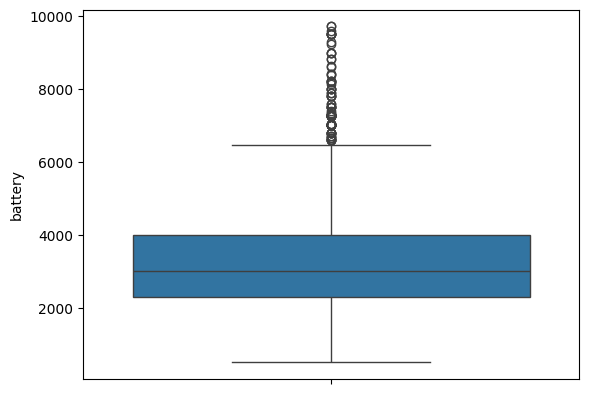

In [59]:
# Visualizing using box plot
sns.boxplot(df_no_outliers['battery'])
plt.show()

In [79]:
# Computing outlier rows and columns for 'battery' attribute
IQR = df['battery'].quantile(0.75) - df['battery'].quantile(0.25)
lower_limit = df['battery'].quantile(0.25) - (IQR * 1.5)
upper_limit = df['battery'].quantile(0.75) + (IQR * 1.5)

outliers_battery = df[(df['battery'] < lower_limit) | (df['battery'] > upper_limit)]

print("Outlier:\n", outliers_battery.shape)

Outlier:
 (77, 15)


Some tablets and phones can have larger battery sizes as their selling point, it makes sense to have few outliers. More investigation still might be required.

**5. main_camera_mp**

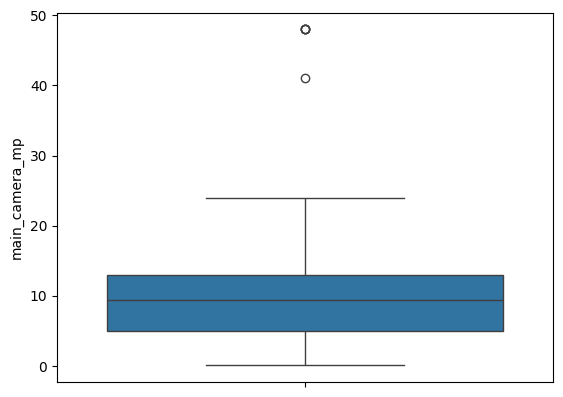

In [87]:
# Visualizing box plot for 'main_camera_mp' attribute
sns.boxplot(df['main_camera_mp'])
plt.show()

we can see that there are few outliers, lets create a data frame with the outliers.

In [88]:
# Computing outlier rows and columns for 'main_camera_mp' attribute
IQR = df['main_camera_mp'].quantile(0.75) - df['main_camera_mp'].quantile(0.25)
lower_limit = df['main_camera_mp'].quantile(0.25) - (IQR * 1.5)
upper_limit = df['main_camera_mp'].quantile(0.75) + (IQR * 1.5)

outliers_maincam = df[(df['main_camera_mp'] < lower_limit) | (df['main_camera_mp'] > upper_limit)]

print("Outlier:\n", outliers_maincam.shape)

Outlier:
 (5, 15)


There are few cellphones in the market with exceptionally good cameras as the main selling point. The outliers look natural, still more investigation could be done.

**6. selfie_camera_mp**

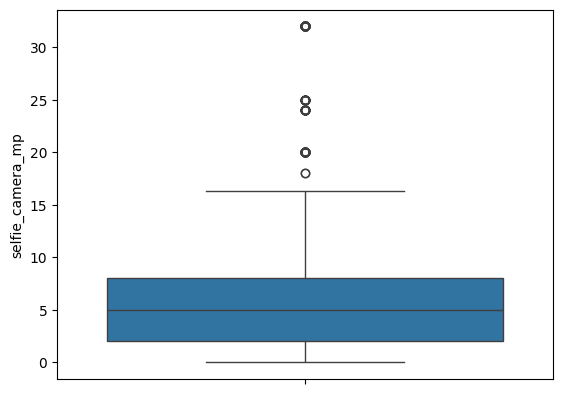

In [90]:
# Visualizing box plot for 'selfie_camera_mp' attribute
sns.boxplot(df['selfie_camera_mp'])
plt.show()

We can see few outliers from the boxplot, lets find those data points.

In [91]:
# Computing outlier rows and columns for 'selfie_camera_mp' attribute
IQR = df['selfie_camera_mp'].quantile(0.75) - df['selfie_camera_mp'].quantile(0.25)
lower_limit = df['selfie_camera_mp'].quantile(0.25) - (IQR * 1.5)
upper_limit = df['selfie_camera_mp'].quantile(0.75) + (IQR * 1.5)

outliers_selfcam = df[(df['selfie_camera_mp'] < lower_limit) | (df['selfie_camera_mp'] > upper_limit)]

print("Outlier:\n", outliers_selfcam.shape)

Outlier:
 (221, 15)


There are few cellphones in the market with exceptionally good selfie cameras as the main selling point. The outliers look natural, still more investigation could be done.

**7. int_memory:**

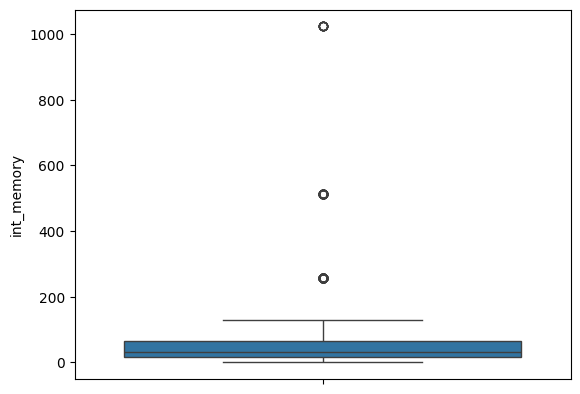

In [93]:
sns.boxplot(df['int_memory'])
plt.show()

From the boxplot we can see that there are few outliers, lets make a dataframe containing those outliers.

In [95]:
# Computing outlier rows and columns for 'int_memory' attribute
IQR = df['int_memory'].quantile(0.75) - df['int_memory'].quantile(0.25)
lower_limit = df['int_memory'].quantile(0.25) - (IQR * 1.5)
upper_limit = df['int_memory'].quantile(0.75) + (IQR * 1.5)

outliers_intmem = df[(df['int_memory'] < lower_limit) | (df['int_memory'] > upper_limit)]

print("Outlier:\n", outliers_intmem.shape)

Outlier:
 (138, 15)


There are some phones or tablets in the market with storage space as their selling point, outliers look natural.

**8. days_used:**

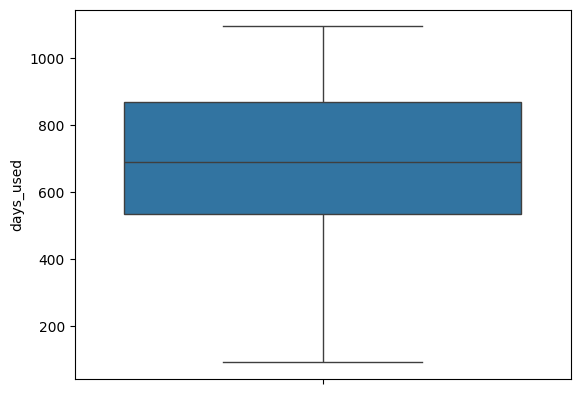

In [97]:
# Visualizing using box plot
sns.boxplot(df['days_used'])
plt.show()

The box plot suggests that there are no outliers, lets check using IQR method.

In [98]:
# Checking for outliers
IQR = df['days_used'].quantile(0.75) - df['days_used'].quantile(0.25)
lower_limit = df['days_used'].quantile(0.25) - (IQR * 1.5)
upper_limit = df['days_used'].quantile(0.75) + (IQR * 1.5)

outliers_daysused = df[(df['days_used'] < lower_limit) | (df['days_used'] > upper_limit)]

print("Outlier:\n", outliers_daysused.shape)

Outlier:
 (0, 15)


There are no outliers for this attribute.

**9. normalized_used_price**

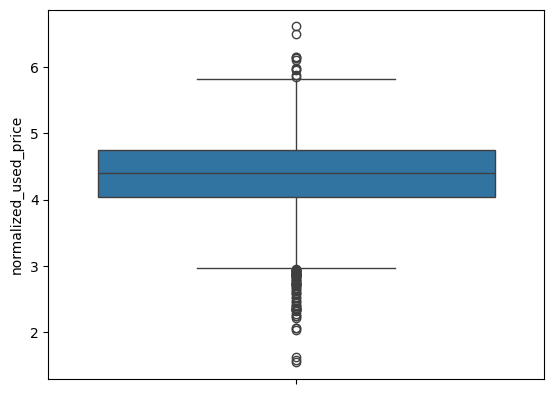

In [99]:
sns.boxplot(df['normalized_used_price'])
plt.show()

The box plot shows that there are multiple outliers in this data set. Lets make a dataframe for those outliers so that it can be investigated further.

In [100]:
# Computing outliers for 'normalized_used_price' attribute
IQR = df['normalized_used_price'].quantile(0.75) - df['normalized_used_price'].quantile(0.25)
lower_limit = df['normalized_used_price'].quantile(0.25) - (IQR * 1.5)
upper_limit = df['normalized_used_price'].quantile(0.75) + (IQR * 1.5)

outliers_normalized_used_price = df[(df['normalized_used_price'] < lower_limit) | (df['normalized_used_price'] > upper_limit)]

print("Outlier:\n", outliers_normalized_used_price.shape)

Outlier:
 (85, 15)


There could be cheap or expensive phones in the market thats more in demand driving up the price, the outliers look natural but more investigation could be done.

**Feature Engineering:**


We will introduce a feature 'model_age' that is difference between the current year and year that particular model was made. As this data was collected in 2021 we will assume the 2021 as current and base our calculations on that.

In [111]:
#Adding model age to the dataset
df['model_age'] = 2021 - df['release_year']


In [112]:
df['model_age'].describe()

,model_age
count,3454.000000
mean,5.034742
std,2.298455
min,1.000000
25%,3.000000
50%,5.500000
75%,7.000000
max,8.000000


In [123]:
df['model_age'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 3454 entries, 0 to 3453
Series name: model_age
Non-Null Count  Dtype
--------------  -----
3454 non-null   int64
dtypes: int64(1)
memory usage: 27.1 KB


Now that we know the age of the model, this will be a good feature to build our regression model. Hence dropping the 'release_year' attribute.

In [ ]:
df.drop('release_year', axis = 1, inplace = True)

In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3454 entries, 0 to 3453
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand_name             3454 non-null   object 
 1   os                     3454 non-null   object 
 2   screen_size            3454 non-null   float64
 3   4g                     3454 non-null   object 
 4   5g                     3454 non-null   object 
 5   main_camera_mp         3454 non-null   float64
 6   selfie_camera_mp       3454 non-null   float64
 7   int_memory             3454 non-null   float64
 8   ram                    3454 non-null   float64
 9   battery                3454 non-null   float64
 10  weight                 3454 non-null   float64
 11  days_used              3454 non-null   int64  
 12  normalized_used_price  3454 non-null   float64
 13  normalized_new_price   3454 non-null   float64
 14  model_age              3454 non-null   int64  
dtypes: f

## EDA

- It is a good idea to explore the data once again after manipulating it.

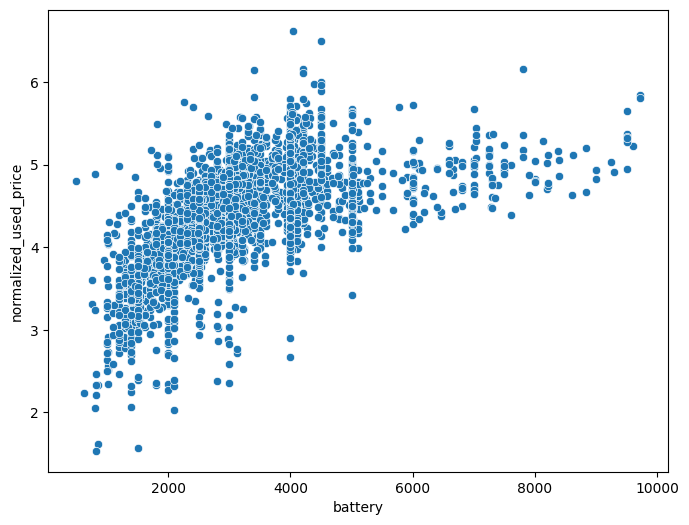

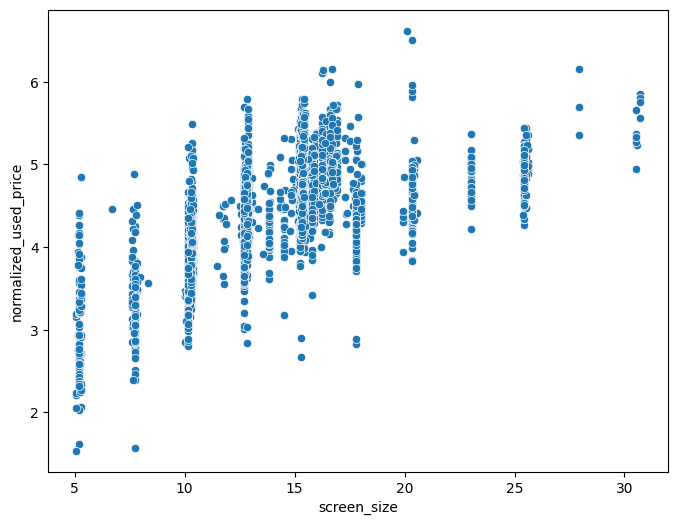

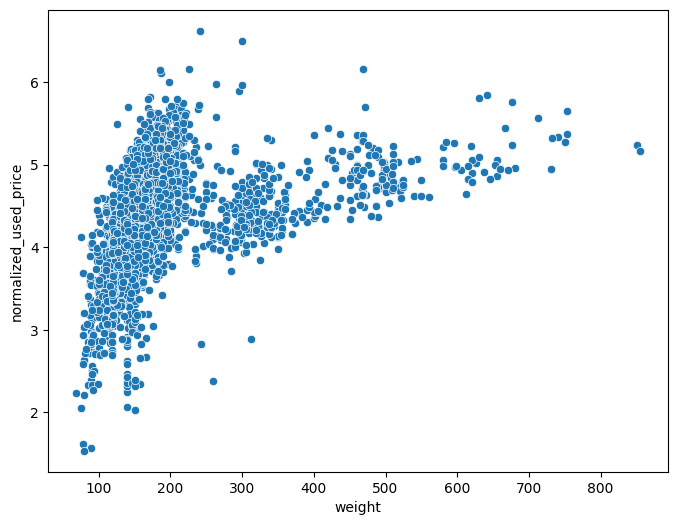

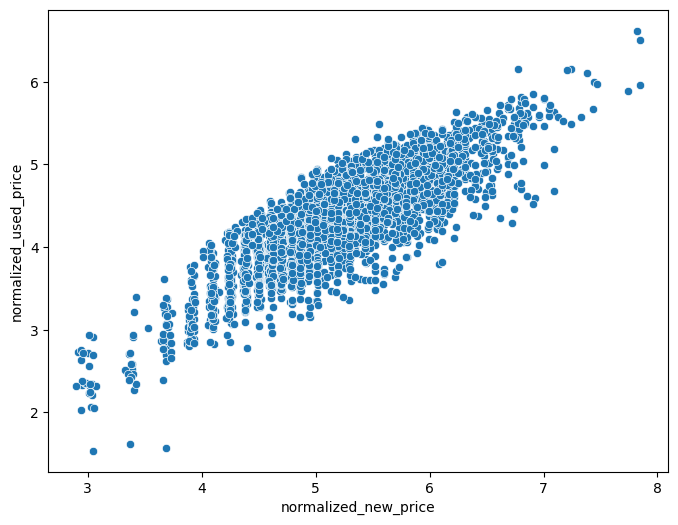

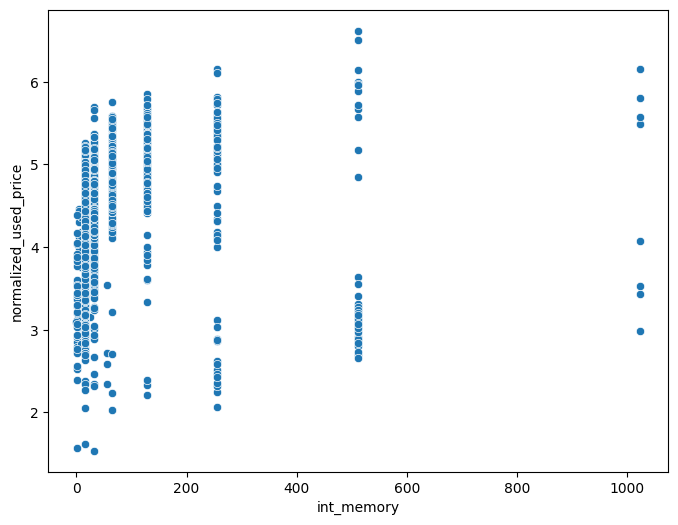

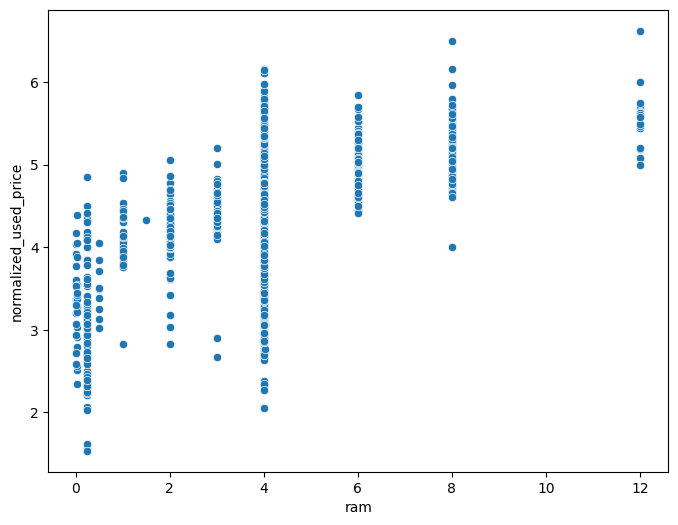

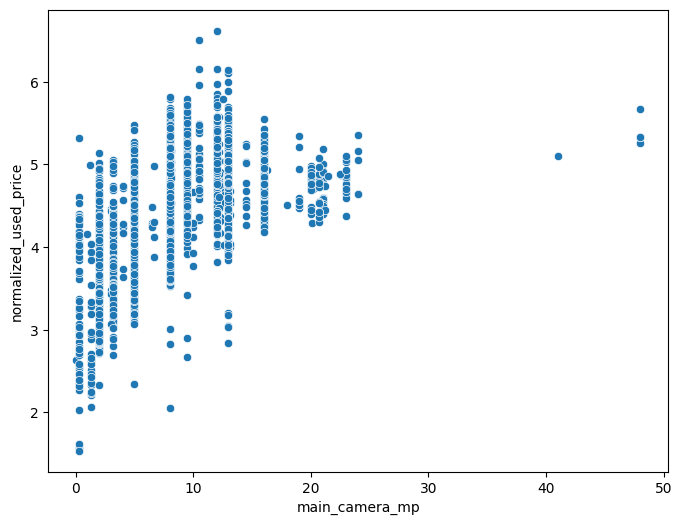

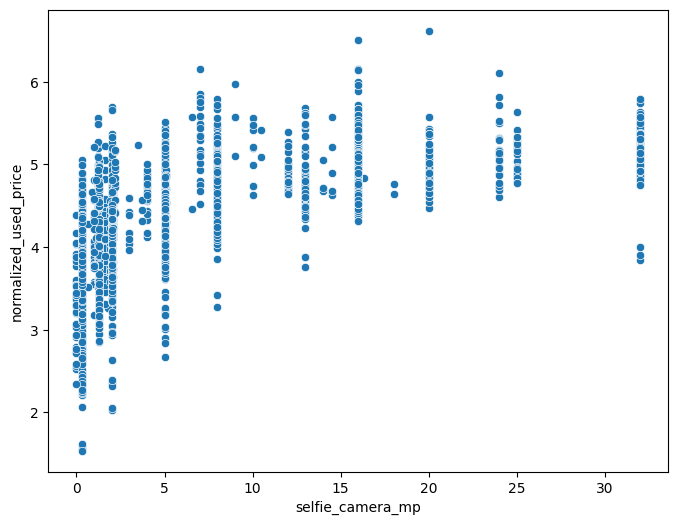

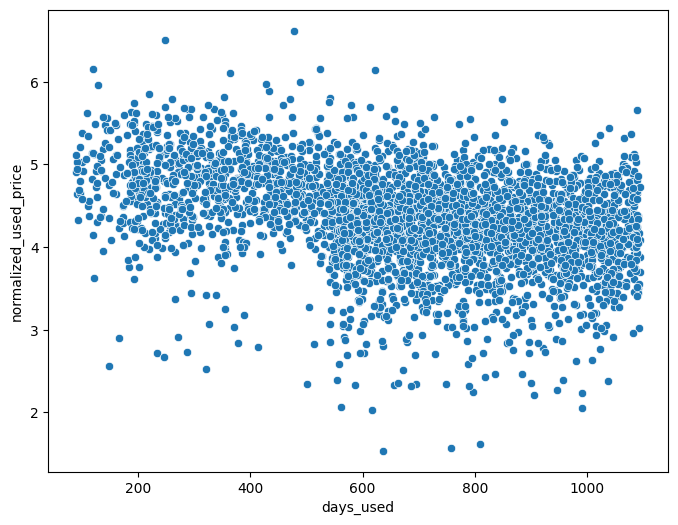

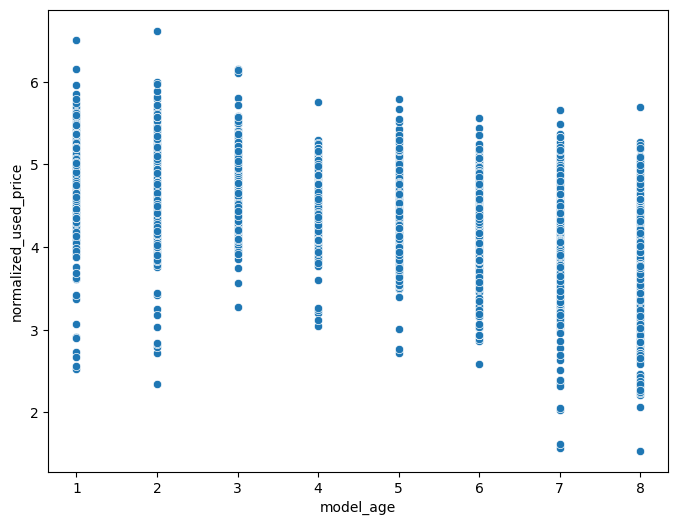

In [117]:
#Scatterplots with y as normalized_used_price and x as different independent attributes
for i in ['battery','screen_size','weight','normalized_new_price', 'int_memory', 'ram','main_camera_mp','selfie_camera_mp','days_used', 'model_age']:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x=i, y="normalized_used_price")
    plt.show()

Some attributes like - Screen size, weight, Battery, norm_new_price exibit clear relationship but we need to dive deeper to detemine the extent of correlations.

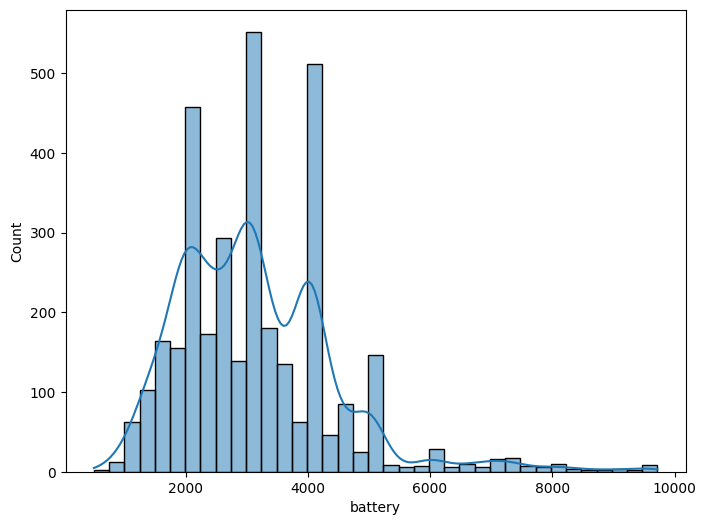

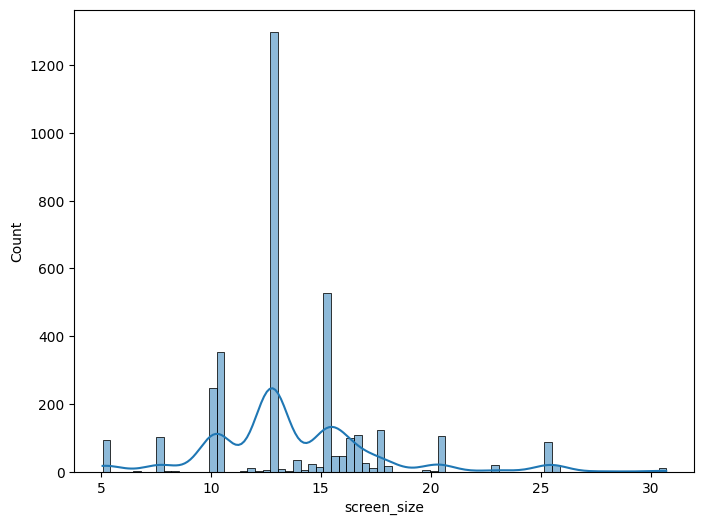

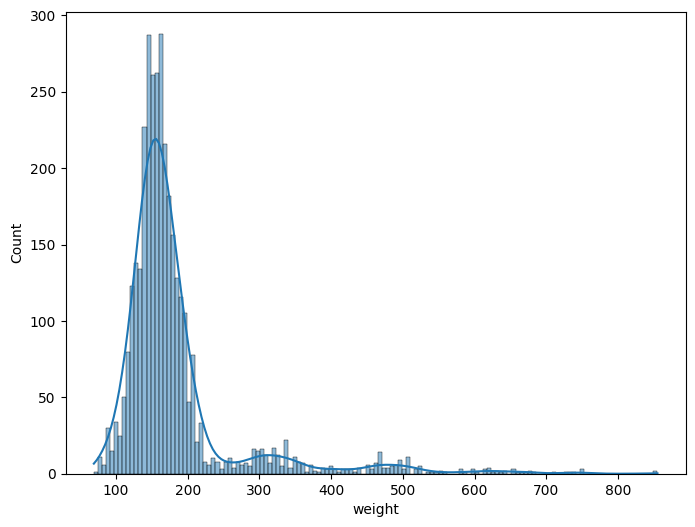

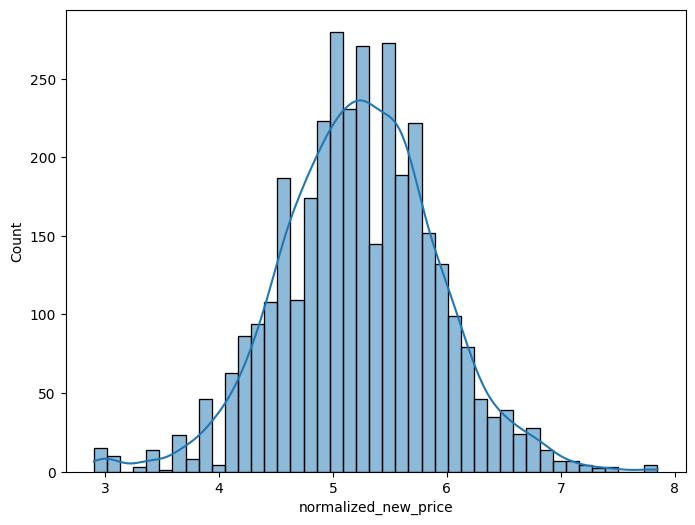

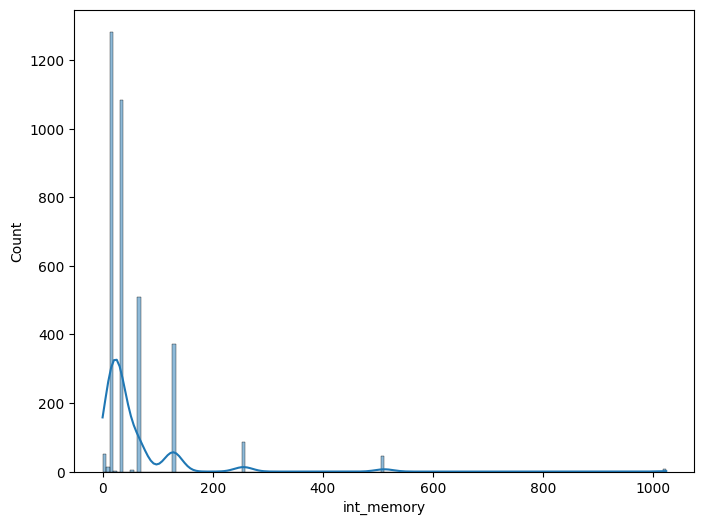

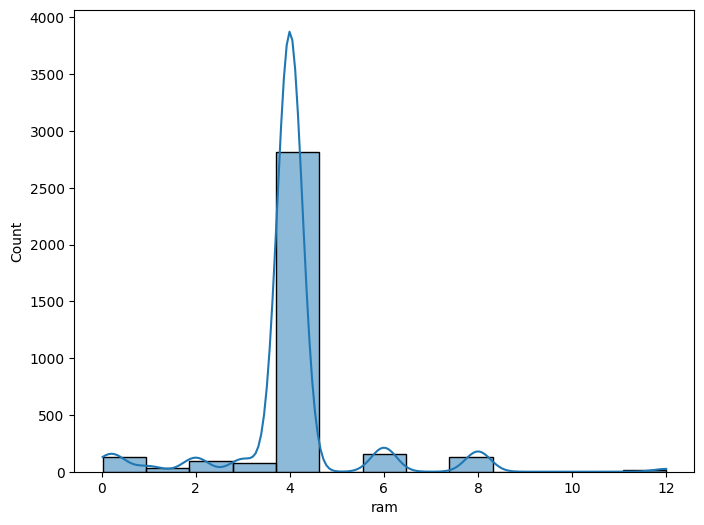

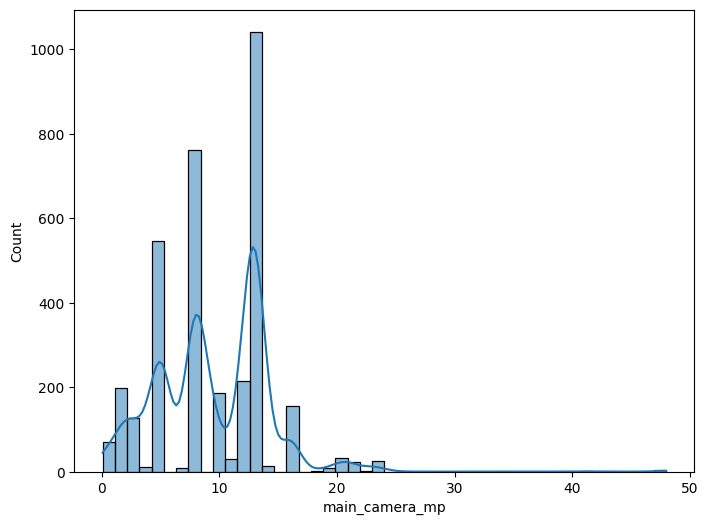

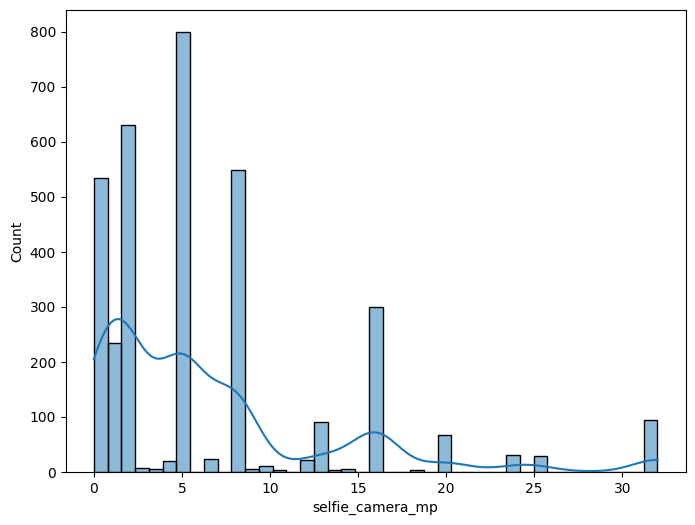

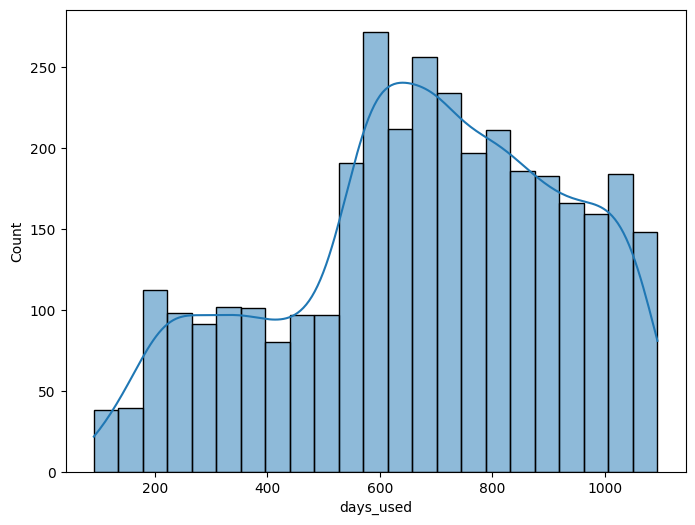

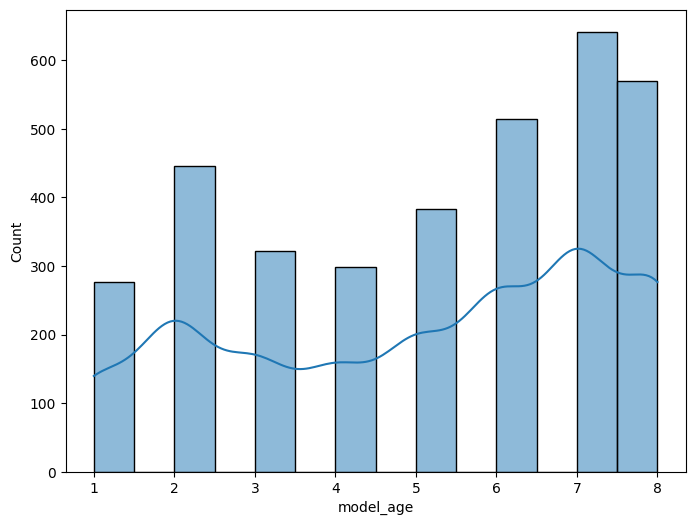

In [118]:
# Visualizing distributions across all the numerical attributes
for i in ['battery','screen_size','weight','normalized_new_price', 'int_memory', 'ram','main_camera_mp','selfie_camera_mp','days_used', 'model_age']:
    plt.figure(figsize=(8, 6))
    sns.histplot(data=df, x=i, kde= True)
    plt.show()

Looking at the distrutions, norm_new_price exibits normal distribution while other variables are skewed or needs to transformation for normality. Lets focus more on correlation between the variables -

<ipython-input-119-681aebb63b04>:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')


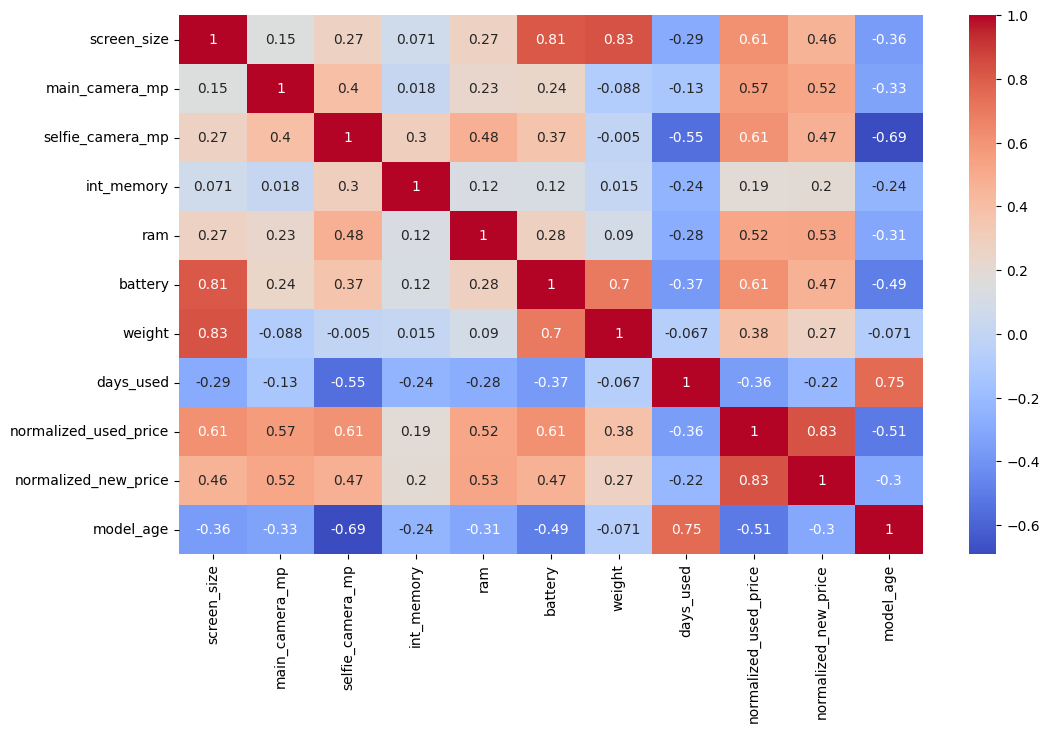

In [119]:
# visualizing correlation using heatmap -
plt.figure(figsize=(12, 7))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')
plt.show()

In [120]:
# listing out the correlation with the dependent variable 'normalized_used_price' -
df.corr()['normalized_used_price'].sort_values(ascending = False)

<ipython-input-120-348c981e2d41>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()['normalized_used_price'].sort_values(ascending = False)


,normalized_used_price
normalized_used_price,1.000000
normalized_new_price,0.834496
screen_size,0.614785
battery,0.611962
selfie_camera_mp,0.607700
main_camera_mp,0.566872
ram,0.518717
weight,0.382143
int_memory,0.190142
days_used,-0.358264


The added feature model_age is negatively correlated to normalized_used_price, that implies as the age increases the price decreases. This looks accurate.

## Model Building - Linear Regression

In [121]:
# Dropping the dependent variable -
X = df.drop('normalized_used_price', axis = 1)
y = df['normalized_used_price']

In [122]:
# Assigning dummy variables for categorical attributes -
X = pd.get_dummies(X, drop_first = True)
X.head()

,screen_size,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,days_used,normalized_new_price,model_age,...,brand_name_Spice,brand_name_Vivo,brand_name_XOLO,brand_name_Xiaomi,brand_name_ZTE,os_Others,os_Windows,os_iOS,4g_yes,5g_yes
0,14.50,13.0,5.0,64.0,3.0,3020.0,146.0,127,4.715100,1,...,0,0,0,0,0,0,0,0,1,0
1,17.30,13.0,16.0,128.0,8.0,4300.0,213.0,325,5.519018,1,...,0,0,0,0,0,0,0,0,1,1
2,16.69,13.0,8.0,128.0,8.0,4200.0,213.0,162,5.884631,1,...,0,0,0,0,0,0,0,0,1,1
3,25.50,13.0,8.0,64.0,6.0,7250.0,480.0,345,5.630961,1,...,0,0,0,0,0,0,0,0,1,1
4,15.32,13.0,8.0,64.0,3.0,5000.0,185.0,293,4.947837,1,...,0,0,0,0,0,0,0,0,1,0


In [128]:
# Adding constant to the dataset
X = sm.add_constant(X)
X.head()

,const,screen_size,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,days_used,normalized_new_price,...,brand_name_Spice,brand_name_Vivo,brand_name_XOLO,brand_name_Xiaomi,brand_name_ZTE,os_Others,os_Windows,os_iOS,4g_yes,5g_yes
0,1.0,14.50,13.0,5.0,64.0,3.0,3020.0,146.0,127,4.715100,...,0,0,0,0,0,0,0,0,1,0
1,1.0,17.30,13.0,16.0,128.0,8.0,4300.0,213.0,325,5.519018,...,0,0,0,0,0,0,0,0,1,1
2,1.0,16.69,13.0,8.0,128.0,8.0,4200.0,213.0,162,5.884631,...,0,0,0,0,0,0,0,0,1,1
3,1.0,25.50,13.0,8.0,64.0,6.0,7250.0,480.0,345,5.630961,...,0,0,0,0,0,0,0,0,1,1
4,1.0,15.32,13.0,8.0,64.0,3.0,5000.0,185.0,293,4.947837,...,0,0,0,0,0,0,0,0,1,0


In [129]:
# Splitting the data set into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1)

In [131]:
# Building the model
model = sm.OLS(y_train, X_train).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                             
=================================================================================
Dep. Variable:     normalized_used_price   R-squared:                       0.845
Model:                               OLS   Adj. R-squared:                  0.842
Method:                    Least Squares   F-statistic:                     268.9
Date:                   Mon, 17 Feb 2025   Prob (F-statistic):               0.00
Time:                           02:52:23   Log-Likelihood:                 124.63
No. Observations:                   2417   AIC:                            -151.3
Df Residuals:                       2368   BIC:                             132.5
Df Model:                             48                                         
Covariance Type:               nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     1.3251      0.071     18.575      0.000       1.185       1.465
screen_size               0.0243      0.003      7.150      0.000       0.018       0.031
main_camera_mp            0.0206      0.001     13.852      0.000       0.018       0.024
selfie_camera_mp          0.0135      0.001     12.043      0.000       0.011       0.016
int_memory                0.0001   6.97e-05      1.575      0.115   -2.69e-05       0.000
ram                       0.0239      0.005      4.643      0.000       0.014       0.034
battery               -1.628e-05   7.27e-06     -2.240      0.025   -3.05e-05   -2.03e-06
weight                    0.0010      0.000      7.474      0.000       0.001       0.001
days_used              3.601e-05   3.09e-05      1.166      0.244   -2.46e-05    9.66e-05
normalized_new_price      0.4305      0.012     35.055      0.000       0.406       0.455
model_age                -0.0243      0.005     -5.333      0.000      -0.033      -0.015
brand_name_Alcatel        0.0155      0.048      0.326      0.744      -0.078       0.109
brand_name_Apple         -0.0101      0.147     -0.068      0.945      -0.298       0.278
brand_name_Asus           0.0182      0.048      0.380      0.704      -0.076       0.112
brand_name_BlackBerry    -0.0366      0.070     -0.521      0.602      -0.174       0.101
brand_name_Celkon        -0.0438      0.066     -0.662      0.508      -0.174       0.086
brand_name_Coolpad        0.0348      0.073      0.477      0.633      -0.108       0.178
brand_name_Gionee         0.0453      0.058      0.784      0.433      -0.068       0.158
brand_name_Google        -0.0322      0.085     -0.381      0.703      -0.198       0.134
brand_name_HTC           -0.0120      0.048     -0.249      0.803      -0.106       0.082
brand_name_Honor          0.0264      0.049      0.538      0.591      -0.070       0.123
brand_name_Huawei        -0.0062      0.044     -0.139      0.890      -0.093       0.081
brand_name_Infinix        0.1281      0.093      1.375      0.169      -0.055       0.311
brand_name_Karbonn        0.0959      0.067      1.429      0.153      -0.036       0.227
brand_name_LG            -0.0142      0.045     -0.314      0.753      -0.103       0.075
brand_name_Lava           0.0311      0.062      0.499      0.618      -0.091       0.153
brand_name_Lenovo         0.0451      0.045      0.997      0.319      -0.044       0.134
brand_name_Meizu          0.0021      0.056      0.037      0.971      -0.108       0.112
brand_name_Micromax      -0.0336      0.048     -0.702      0.483      -0.127       0.060
brand_name_Microsoft      0.0954      0.088      1.081      0.280      -0.078       0.269
brand_name_Motorola      -0.0002      0.050     -0.004      0.996      -0.097   

In [133]:
# Co-efficient of determination
print("The coefficient of determination (R-squared) is ", model.rsquared)

The coefficient of determination (R-squared) is  0.8449855226507753


This means the model can explain 84% of the datasets variability, lets check how model performs now.

## Model Performance Check

In [135]:
# Checking the model performance
y_pred = model.predict(X_test)
y_pred.head()

,0
866,4.221079
957,3.277506
280,4.255593
2150,4.742836
93,4.507248


In [137]:
# Calculating the MSE for training set
print("The Mean Square Error (MSE) of the model for the training set is ", mean_squared_error(y_train, model.predict(X_train)),)
print ("The MSE of model based on residuals for training set is", model.mse_resid)

The Mean Square Error (MSE) of the model for the training set is  0.052812658216999216
The MSE of model based on residuals for training set is 0.05390548771557732


In [139]:
# Calculating MSE for testing set
print("The Mean Square Error (MSE) of the model for the testing set is ", mean_squared_error(y_test, model.predict(X_test)))

The Mean Square Error (MSE) of the model for the testing set is  0.05677336974741377


In [141]:
# RMSE for training set
print("The Root Mean Square Error (RMSE) of the model for the training set is ", np.sqrt(mean_squared_error(y_train, model.predict(X_train))))

print ("The RMSE of model based on residuals for training set is", np.sqrt(model.mse_resid))

The Root Mean Square Error (RMSE) of the model for the training set is  0.2298100481201795
The RMSE of model based on residuals for training set is 0.23217555365623083


In [142]:
# RMSE for testing set
print("The Root Mean Square Error (RMSE) of the model for the testing set is ", np.sqrt(mean_squared_error(y_test, model.predict(X_test))))

The Root Mean Square Error (RMSE) of the model for the testing set is  0.23827163017743797


The RMSE training set is slightly lower than RMSE for testing set, the model is slightly overfit but the difference is low. MSE Train is lower than MSE test by approx 4% which indicates that the model is overfitting. Lets check the assumptions now.

## Checking Linear Regression Assumptions

- In order to make statistical inferences from a linear regression model, it is important to ensure that the assumptions of linear regression are satisfied.

1. Checking for Multicolinearity using VIF -


In [143]:
# Defining a function to compute VIF on predictor columns -
def checking_vif(predictors):
    vif = pd.DataFrame()
    vif["feature"] = predictors.columns

    # calculating VIF for each feature
    vif["VIF"] = [
        variance_inflation_factor(predictors.values, i)
        for i in range(len(predictors.columns))
    ]
    return vif

In [145]:
# Computing VIF
checking_vif(X_train).sort_values(by = 'VIF', ascending = False)

,feature,VIF
0,const,228.192463
12,brand_name_Apple,13.056484
46,os_iOS,11.784282
34,brand_name_Others,9.710624
1,screen_size,7.674511
37,brand_name_Samsung,7.539609
7,weight,6.376012
21,brand_name_Huawei,5.985521
10,model_age,4.885974
24,brand_name_LG,4.849084


In [149]:
# Defining a function that calculates adj. R-squared and RMSE values

def treating_multicollinearity(predictors, target, high_vif_columns):
    """
    Checking the effect of dropping the columns showing high multicollinearity
    on model performance (adj. R-squared and RMSE)

    predictors: independent variables
    target: dependent variable
    high_vif_columns: columns having high VIF
    """
    # empty lists to store adj. R-squared and RMSE values
    adj_r2 = []
    rmse = []

    # build ols models by dropping one of the high VIF columns at a time
    # store the adjusted R-squared and RMSE in the lists defined previously
    for cols in high_vif_columns:
        # defining the new train set
        train = predictors.loc[:, ~predictors.columns.str.startswith(cols)]

        # create the model
        olsmodel = sm.OLS(target, train).fit()

        # adding adj. R-squared and RMSE to the lists
        adj_r2.append(olsmodel.rsquared_adj)
        rmse.append(np.sqrt(olsmodel.mse_resid))

    # creating a dataframe for the results
    temp = pd.DataFrame(
        {
            "col": high_vif_columns,
            "Adj. R-squared after_dropping col": adj_r2,
            "RMSE after dropping col": rmse,
        }
    ).sort_values(by="Adj. R-squared after_dropping col", ascending=False)
    temp.reset_index(drop=True, inplace=True)

    return temp

In [164]:
#Checking Adj R squared and RMSE after dropping the columns
vif_list = ['brand_name_Apple','os_iOS','brand_name_Others','screen_size']

res = treating_multicollinearity(X_train, y_train, vif_list)
res

,col,Adj. R-squared after_dropping col,RMSE after dropping col
0,brand_name_Apple,0.841910,0.232127
1,brand_name_Others,0.841908,0.232128
2,os_iOS,0.841899,0.232135
3,screen_size,0.838497,0.234619


In [167]:
X1_train = X_train.drop(columns = ['brand_name_Apple','os_iOS','brand_name_Others','screen_size'])
X1_test = X_test.drop(columns = ['brand_name_Apple','os_iOS','brand_name_Others','screen_size'])

checking_vif(X1_train).sort_values(by = 'VIF', ascending = False)

,feature,VIF
0,const,130.399822
9,model_age,4.692346
5,battery,3.822570
6,weight,2.970303
8,normalized_new_price,2.910680
2,selfie_camera_mp,2.766157
7,days_used,2.654395
43,4g_yes,2.449788
4,ram,2.239598
1,main_camera_mp,2.164252


We have treated multicolinearity by dropping the columns 'brand_name_Apple','os_iOS','brand_name_Others','screen_size' as these attributes had hight VIF values. Now all attributes have VIF less than 5.

2. Drop high P-value variables -

In [165]:
cols = X1_train.columns.tolist()

# setting an initial max p-value
max_p_value = 1

while len(cols) > 0:
    # defining the train set
    x_train_aux = X1_train[cols]

    # fitting the model
    model = sm.OLS(y_train, x_train_aux).fit()

    # getting the p-values and the maximum p-value
    p_values = model.pvalues
    max_p_value = max(p_values)

    # name of the variable with maximum p-value
    feature_with_p_max = p_values.idxmax()

    if max_p_value > 0.05:
        cols.remove(feature_with_p_max)
    else:
        break

selected_features = cols
print(selected_features)

['const', 'main_camera_mp', 'selfie_camera_mp', 'ram', 'weight', 'normalized_new_price', 'model_age', 'brand_name_Karbonn', 'brand_name_Lenovo', 'brand_name_Xiaomi', 'os_Others', '4g_yes']


In [168]:
X2_train = X1_train[selected_features]
X2_test = X1_test[selected_features]

In [169]:
model2 = sm.OLS(y_train, X2_train).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                             
=================================================================================
Dep. Variable:     normalized_used_price   R-squared:                       0.839
Model:                               OLS   Adj. R-squared:                  0.838
Method:                    Least Squares   F-statistic:                     1138.
Date:                   Mon, 17 Feb 2025   Prob (F-statistic):               0.00
Time:                           03:48:49   Log-Likelihood:                 77.337
No. Observations:                   2417   AIC:                            -130.7
Df Residuals:                       2405   BIC:                            -61.19
Df Model:                             11                                         
Covariance Type:               nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    1.5551      0.046     33.446      0.000       1.464       1.646
main_camera_mp           0.0213      0.001     15.480      0.000       0.019       0.024
selfie_camera_mp         0.0143      0.001     13.362      0.000       0.012       0.016
ram                      0.0193      0.004      4.339      0.000       0.011       0.028
weight                   0.0016   6.02e-05     27.326      0.000       0.002       0.002
normalized_new_price     0.4315      0.011     39.962      0.000       0.410       0.453
model_age               -0.0305      0.003     -9.238      0.000      -0.037      -0.024
brand_name_Karbonn       0.1211      0.055      2.211      0.027       0.014       0.229
brand_name_Lenovo        0.0509      0.022      2.351      0.019       0.008       0.093
brand_name_Xiaomi        0.0921      0.026      3.589      0.000       0.042       0.142
os_Others               -0.1350      0.027     -5.006      0.000      -0.188      -0.082
4g_yes                   0.0462      0.015      3.073      0.002       0.017       0.076
==============================================================================
Omnibus:                      237.298   Durbin-Watson:                   1.908
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              452.026
Skew:                          -0.648   Prob(JB):                     6.98e-99
Kurtosis:                       4.676   Cond. No.                     2.37e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.37e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Dropping attributes with high p-values did not significantly affect R-squared or Adj R-squared values.

**3. Test for Linearity and Independence**

In [170]:
# creating a dataframe containing actual, fitted and residual values to check for linearity and independence
df_pred = pd.DataFrame()

df_pred["Actual Values"] = y_train  # actual values
df_pred["Fitted Values"] = model2.fittedvalues  # predicted values
df_pred["Residuals"] = model2.resid  # residuals

df_pred.head()

,Actual Values,Fitted Values,Residuals
3026,4.087488,3.860380,0.227108
1525,4.448399,4.640139,-0.191739
1128,4.315353,4.280879,0.034474
3003,4.282068,4.276876,0.005192
2907,4.456438,4.489053,-0.032614


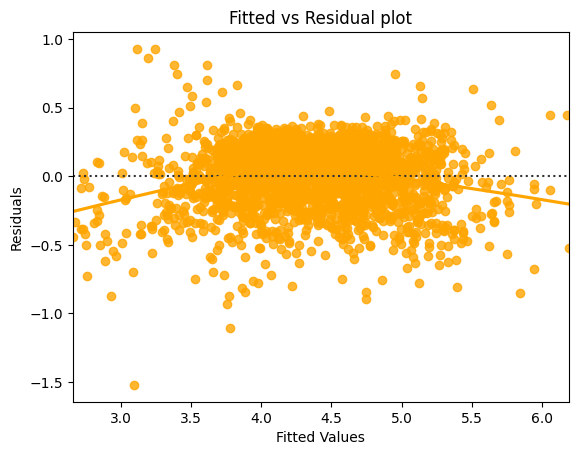

In [173]:
# let's plot the fitted values vs residuals

sns.residplot(
    data=df_pred, x="Fitted Values", y="Residuals", color="orange", lowess = True)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Fitted vs Residual plot")
plt.show()

No pattern is observed from the graph, thus assumptions for linearity and independence is satisfied.

**3. Test for Normality**

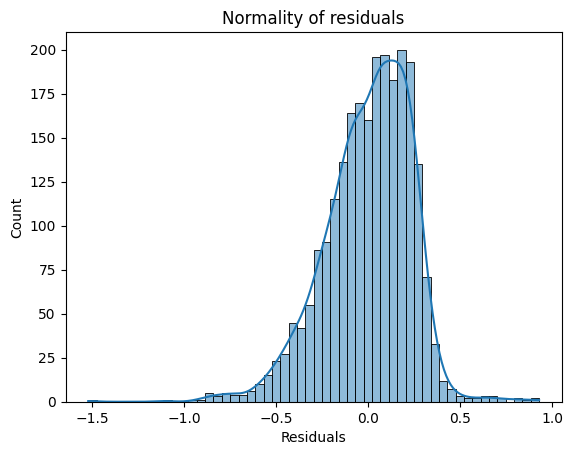

In [174]:
# Visualizing the residuals using histogram
sns.histplot(data=df_pred, x="Residuals", kde=True)
plt.title("Normality of residuals")
plt.show()

A bell shaped pattern is observed indicating that residuals are almost normally distributed.

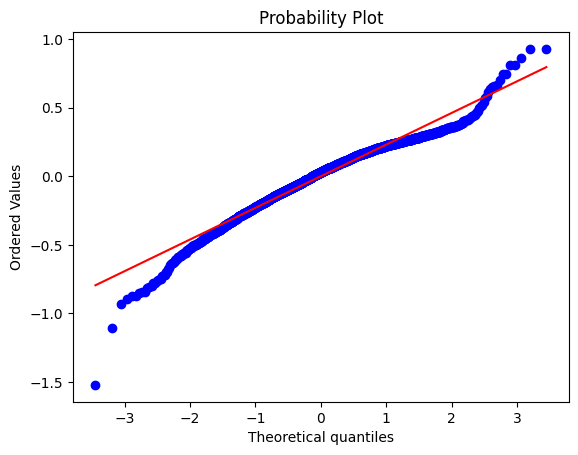

In [175]:
# Visualizing using Q-Q plots
import pylab
import scipy.stats as stats

stats.probplot(df_pred["Residuals"], dist="norm", plot=pylab)
plt.show()

We can observe that most of the residuals are on the 45 degree line straight line.

In [176]:
# Checking for normality using Shapiro-Wilk's test -
stats.shapiro(df_pred["Residuals"])

ShapiroResult(statistic=0.9685510267290868, pvalue=1.3744752885832883e-22)

As p-value is < 0.05, residuals are not normal per Shapiro-Wilk's test. But the other tests are indicating an almost normal distribution. Hence, the assumption is satisfied.

**4. Test for Homoscedasticity**

In [178]:
# using the goldfeldquandt test
import statsmodels.stats.api as sms
from statsmodels.compat import lzip

name = ["F statistic", "p-value"]
test = sms.het_goldfeldquandt(df_pred["Residuals"], X2_train)
lzip(name, test)

[('F statistic', 1.0107436645686843), ('p-value', 0.42669600953089637)]

As the p-value > 0.05, we can say that the residuals are homoscedastic. Hence assumption that the residuals are homoscedastic is satisfied.


**From all the tests above we can say that all assumptions of linear regression are satified and we can build the final model.**

## Final Model

In [180]:
model_final = sm.OLS(y_train, X2_train).fit()
print(model_final.summary())

                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.839
Model:                               OLS   Adj. R-squared:                  0.838
Method:                    Least Squares   F-statistic:                     1138.
Date:                   Mon, 17 Feb 2025   Prob (F-statistic):               0.00
Time:                           04:02:41   Log-Likelihood:                 77.337
No. Observations:                   2417   AIC:                            -130.7
Df Residuals:                       2405   BIC:                            -61.19
Df Model:                             11                                         
Covariance Type:               nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
co

In [182]:
# Building the equation for the model -
Equation = "Norm_used_price ="
print(Equation, end=" ")
for i in range(len(X2_train.columns)):
    if i == 0:
        print(model.params[i], "+", end=" ")
    elif i != len(X2_train.columns) - 1:
        print(
            "(",
            model.params[i],
            ")*(",
            X2_train.columns[i],
            ")",
            "+",
            end=" ",
        )
    else:
        print("(", model.params[i], ")*(", X2_train.columns[i], ")")

Norm_used_price = 1.555093128317861 + ( 0.021293523652648902 )*( main_camera_mp ) + ( 0.014255836922603881 )*( selfie_camera_mp ) + ( 0.019272301706788238 )*( ram ) + ( 0.0016450398263480174 )*( weight ) + ( 0.4315044582629376 )*( normalized_new_price ) + ( -0.030487956860452806 )*( model_age ) + ( 0.12112208128729841 )*( brand_name_Karbonn ) + ( 0.05092995856855973 )*( brand_name_Lenovo ) + ( 0.09209664452495381 )*( brand_name_Xiaomi ) + ( -0.1350119516173239 )*( os_Others ) + ( 0.04618535775675197 )*( 4g_yes )


In [183]:
# Testing the Model performance
y_pred = model_final.predict(X2_test)
y_pred.head()

,0
866,4.196353
957,3.293909
280,4.165440
2150,4.738227
93,4.527829


In [184]:
# MSE on training set
print("The Mean Square Error (MSE) of the model for the training set is ", mean_squared_error(y_train, model_final.predict(X2_train)))

print ("The MSE of model based on residuals for training set is", model_final.mse_resid)

The Mean Square Error (MSE) of the model for the training set is  0.05492036085179754
The MSE of model based on residuals for training set is 0.05519439175833457


In [185]:
# MSE on testing set
print("The Mean Square Error (MSE) of the model for the testing set is ", mean_squared_error(y_test, model_final.predict(X2_test)))


The Mean Square Error (MSE) of the model for the testing set is  0.05849056796828909


In [187]:
# RMSE on training set
print("The Root Mean Square Error (RMSE) of the model for the training set is ", np.sqrt(mean_squared_error(y_train, model_final.predict(X2_train))))

print ("The RMSE of model based on residuals for training set is", np.sqrt(model_final.mse_resid))

The Root Mean Square Error (RMSE) of the model for the training set is  0.23435093524839523
The RMSE of model based on residuals for training set is 0.2349348670553917


In [188]:
# RMSE on testing set
print("The Root Mean Square Error (RMSE) of the model for the testing set is ", np.sqrt(mean_squared_error(y_test, model_final.predict(X2_test))))

The Root Mean Square Error (RMSE) of the model for the testing set is  0.2418482333371263


We can infer that model is performing well based on RMSE and MSE values. There are slight overfitting tendencies.

Inferences from the Model -


1.   A unit increase in main_camera_mp increases the price by 0.0212 units, all other varibles held constant.
2.   A unit increase in selfie_camera_mp increases the price by 0.0142 units, all other varibles held constant.
3. A unit increase in ram increases the price by 0.019 units, all other varibles held constant.
4. A unit increase in weight increases the price by 0.0016 units, all other varibles held constant.
5. A unit increase in normalized_new_price increases the price by 0.431 units, all other varibles held constant.
6. A unit increase in model_age decreases the price by 0.0304 units, all other varibles held constant.
7. A unit increase in brand_name_Karbonn increases the price by 0.121 units, all other varibles held constant.
8. A unit increase in brand_name_lenovo increases the price by 0.05 units, all other varibles held constant.
9. A unit increase in brand_name_Xiaomi increases the price by 0.092 units, all other varibles held constant.
10. A unit increase in os_Others decreases the price by 0.135 units, all other varibles held constant.
11. A unit increase in 4g_yes increases the price by 0.046 units, all other varibles held constant.


## Actionable Insights and Recommendations

**Actionable Insights -**
1. The data should be investigated for outliers.
2. Cell phone and tablet data if separated can provide a better insights as they are different market categories for dynamic pricing.
3. Few phones have screen size less that 2 inches and those should be categorized under different phone segment.
4. The factors that influence the price of the refurbished phone are -


    * 4G Compatibility
    * Brands like Xiaomi, Lenovo, Karbonn increases the price of refurbished cell phones.
    * Cells phones and tablets prices depreciate as they get older.
    * Expensive models usually can sell at a higher price after refurbishing.
    * Models with more RAM, main camera mega pixels and selfie camera mega pixels can sell at a higher price after refurbishing.

  5. ReCell should collect data around the supply and demand, eg a demand co-efficient, of different brands that can have an affect on refurbished phone prices.
  6. Introducing a customer segment data can provide insights on the probability of a customer buying a refurbished cell phone at a certain price point.
  7. Recell should collect data around insurance or warrantly that can impact the refurbished phone prices.


**Recommendations**
 1. ReCell should focus to gather customer data that can drive customer segmentation, thereby targeting potential customers.
 2. ReCell should segment their products under distinct categories like touch screen cell phone, branded cell phones, Tablets to enhance their dynamic pricing model.
 3. ReCell should market their brand as an Environmentally conscious brand to attract customers.
 4. ReCell should provide visibility into cost savings offered to the customer while marketing to the customer segments.
 5. ReCell should introduce more features like insured devices and seasonal offers to attract customers.




___